In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

result_dir = "/mnt/oss_nanhu100TB/default/zjq/results/SpecFun/result"

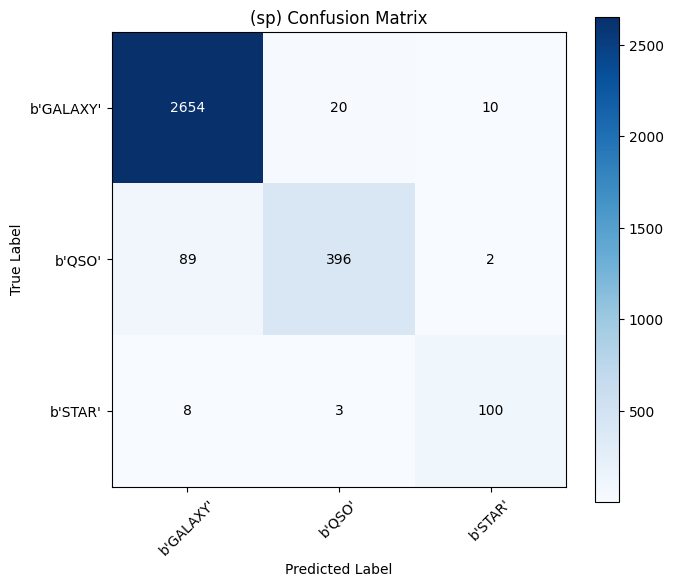

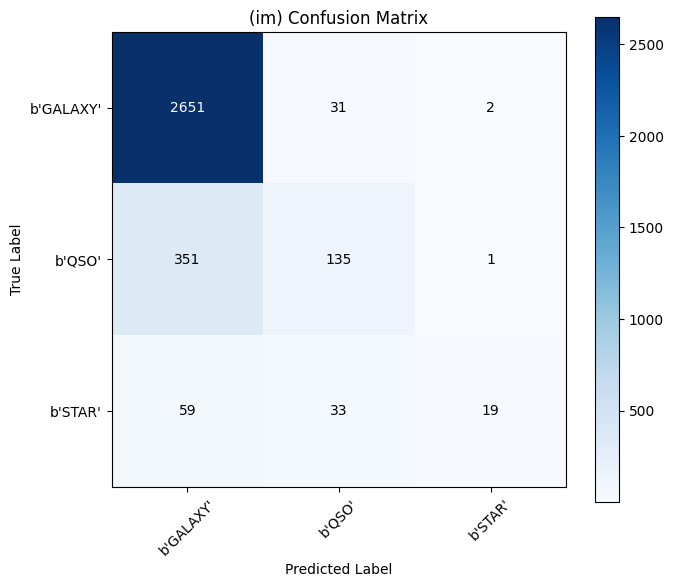

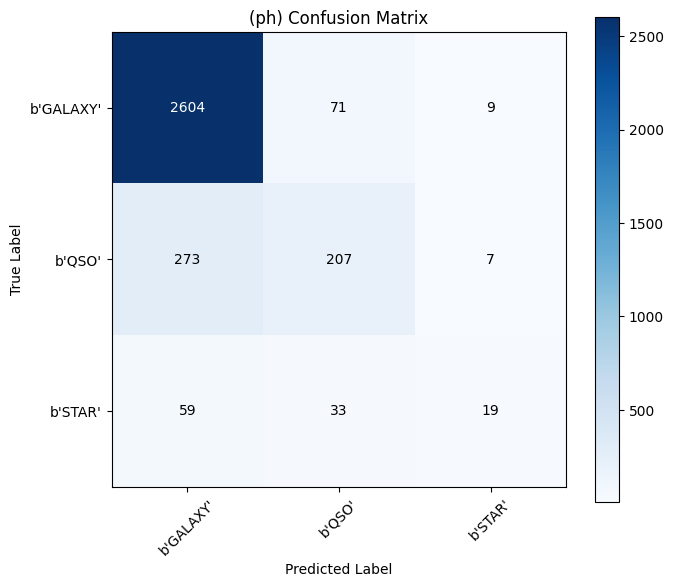

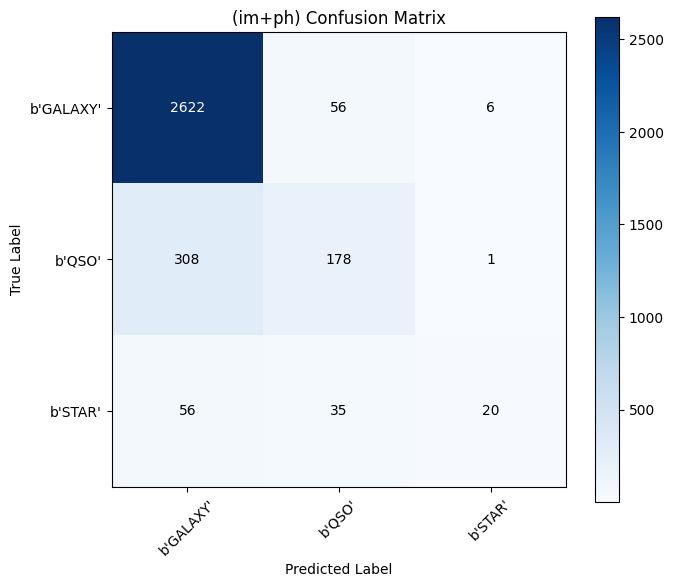

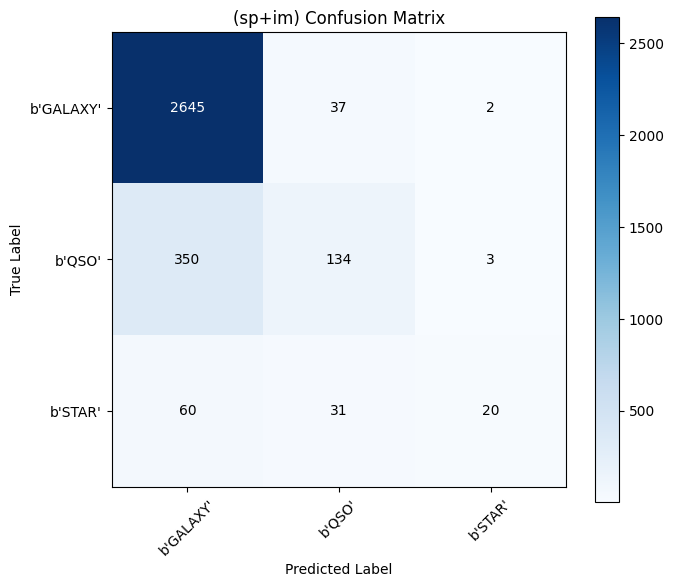

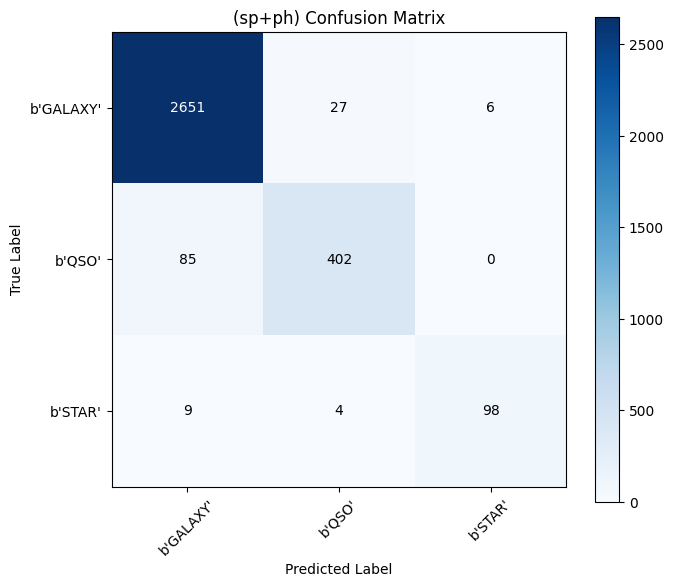

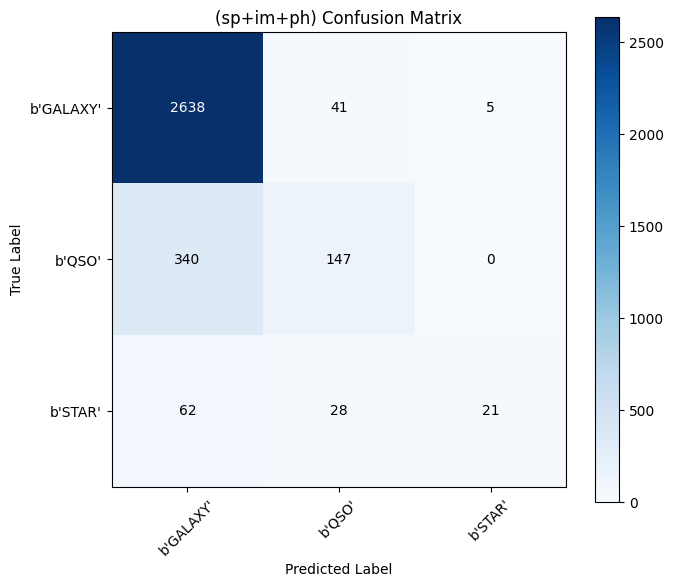

In [5]:
dataset = "desi-sv1" #desi-sv1, provabgs
mods = ["sp", "im", "ph", "im+ph", "sp+im", "sp+ph", "sp+im+ph"]
# mods = ["sp", "ph", "sp+im", "sp+im+ph"]

results = {}

for mod in mods:
    prefix = f"{dataset}_{mod}_type"
    path = os.path.join(result_dir, dataset, f"{prefix}_classification_test_predictions.npz")

    result = np.load(path, allow_pickle=True)
    y_true = result["test_true"]
    y_pred = result["test_pred"]
    classes = result["classes"]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7,6))

    im = plt.imshow(cm, cmap="Blues")
    plt.colorbar(im)

    plt.title(f"({mod}) Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks(range(len(classes)), classes, rotation=45)
    plt.yticks(range(len(classes)), classes)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "black"
            plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

    plt.tight_layout()

    # save_path = os.path.join(result_dir, f"{prefix}_confusion_matrix.png")
    # plt.savefig(save_path, dpi=300)
    plt.show()

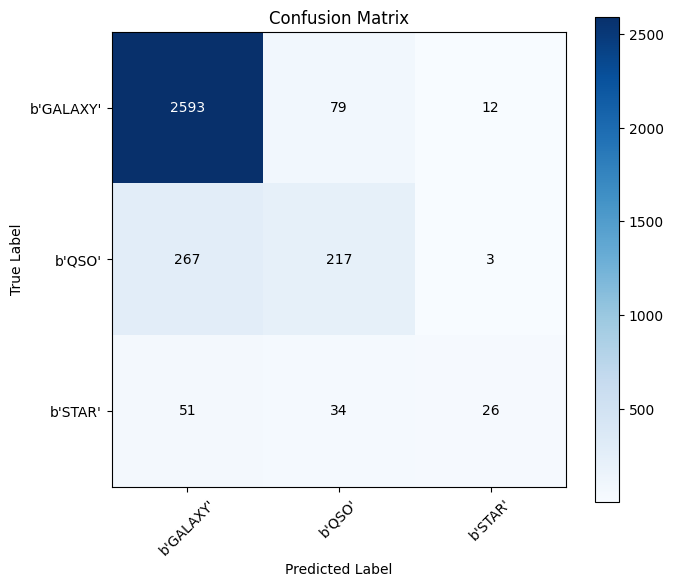

In [22]:


result = np.load(path, allow_pickle=True)

y_true = result["test_true"]
y_pred = result["test_pred"]
classes = result["classes"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

im = plt.imshow(cm, cmap="Blues")
plt.colorbar(im)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

# threshold for text color
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.tight_layout()